# Notebook 3 - Previous Application Exploratory Analysis

This notebook explores the previous-application dataset. It contains information about earlier Home Credit applications made by the applicants.

The analysis checks the structure of the data, previous-application coverage, missing values, placeholder values, application decisions, financial amounts and unusual records. It also examines whether an applicant's previous application history is related to default.

## Import libraries


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
sns.set_style("whitegrid")

BLUE = "#2E6DB4"
ORANGE = "#E67E22"

print("Libraries imported successfully.")


Libraries imported successfully.


## Set file paths


In [5]:
previous_path = "data/raw/previous_application.csv"
application_path = "data/raw/application_train.csv"


## Load the data


In [7]:
previous = pd.read_csv(previous_path)
application_target = pd.read_csv(application_path, usecols=["SK_ID_CURR", "TARGET"])

print("Previous-application rows:", previous.shape[0])
print("Previous-application columns:", previous.shape[1])
print("Labelled applicants:", len(application_target))
previous.head()


Previous-application rows: 1670214
Previous-application columns: 37
Labelled applicants: 307511


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,Y,1,0.0,0.182832,0.867336,XAP,Approved,-73,Cash through the bank,XAP,NaN,Repeater,Mobile,POS,XNA,Country-wide,35,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-164,XNA,XAP,Unaccompanied,Repeater,XNA,Cash,x-sell,Contact center,-1,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-301,Cash through the bank,XAP,"Spouse, partner",Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,Y,1,NaN,NaN,NaN,XNA,Approved,-512,Cash through the bank,XAP,NaN,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,Y,1,NaN,NaN,NaN,Repairs,Refused,-781,Cash through the bank,HC,NaN,Repeater,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


This file has more rows than the application file, because one applicant can have several previous applications. SK_ID_PREV is the ID for each previous application, and SK_ID_CURR links it to the current applicant. This data will be summarized into one row per applicant later.


## Structure, keys, and duplicate checks


In [10]:
print("Exact duplicate rows:", previous.duplicated().sum())
print("Duplicate SK_ID_PREV values:", previous["SK_ID_PREV"].duplicated().sum())
print("Missing SK_ID_PREV values:", previous["SK_ID_PREV"].isna().sum())
print("Missing SK_ID_CURR values:", previous["SK_ID_CURR"].isna().sum())
print("Unique previous applications:", previous["SK_ID_PREV"].nunique())
print("Unique applicants in the complete file:", previous["SK_ID_CURR"].nunique())


Exact duplicate rows: 0
Duplicate SK_ID_PREV values: 0
Missing SK_ID_PREV values: 0
Missing SK_ID_CURR values: 0
Unique previous applications: 1670214
Unique applicants in the complete file: 338857


The IDs are clean. There are no duplicate or missing values.


In [12]:
numeric_columns = previous.select_dtypes(include="number").columns.tolist()
categorical_columns = previous.select_dtypes(exclude="number").columns.tolist()

print("Numeric columns:", len(numeric_columns))
print("Categorical columns:", len(categorical_columns))
previous.dtypes.astype(str).value_counts().to_frame("column_count")


Numeric columns: 21
Categorical columns: 16


,column_count
str,16
float64,15
int64,6


## Previous application coverage

Checking how many applicants have previous application records.


In [14]:
labelled_applicant_ids = set(application_target["SK_ID_CURR"])
previous_applicant_ids = set(previous["SK_ID_CURR"])

applicants_with_previous_history = labelled_applicant_ids.intersection(previous_applicant_ids)
applicants_without_previous_history = labelled_applicant_ids.difference(previous_applicant_ids)
other_previous_applicants = previous_applicant_ids.difference(labelled_applicant_ids)

coverage_percent = len(applicants_with_previous_history) / len(labelled_applicant_ids) * 100

print("Labelled applicants with previous applications:", len(applicants_with_previous_history))
print("Previous-application coverage:", round(coverage_percent, 2), "%")
print("Labelled applicants without previous applications:", len(applicants_without_previous_history))
print("Other applicants in the previous-application file:", len(other_previous_applicants))

Labelled applicants with previous applications: 291057
Previous-application coverage: 94.65 %
Labelled applicants without previous applications: 16454
Other applicants in the previous-application file: 47800


94.65% of applicants have previous-application history. The extra 47,800 IDs that are not in application_train are probably from the separate test file.


### Default rate with and without previous Home Credit history


,count,default_rate_percent
HAS_PREVIOUS_APPLICATION,,
False,16454,5.96
True,291057,8.19


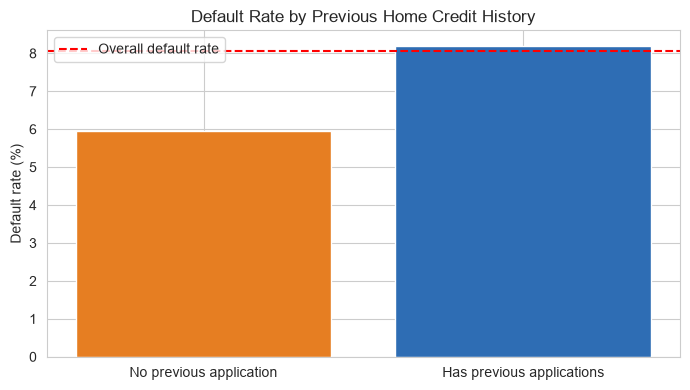

In [17]:
coverage_table = application_target.copy()
coverage_table["HAS_PREVIOUS_APPLICATION"] = coverage_table["SK_ID_CURR"].isin(previous_applicant_ids)

coverage_default_summary = coverage_table.groupby("HAS_PREVIOUS_APPLICATION")["TARGET"].agg(["count", "mean"])
coverage_default_summary["default_rate_percent"] = coverage_default_summary["mean"] * 100
display(coverage_default_summary.drop(columns="mean").round(2))

plot_values = coverage_default_summary["default_rate_percent"]

plt.figure(figsize=(7, 4))
plt.bar(["No previous application", "Has previous applications"], plot_values, color=[ORANGE, BLUE])
plt.axhline(application_target["TARGET"].mean() * 100, color="red", linestyle="--", label="Overall default rate")
plt.ylabel("Default rate (%)")
plt.title("Default Rate by Previous Home Credit History")
plt.legend()
plt.tight_layout()
plt.show()

Having previous applications does not cause default, but the presence of this history could still be a useful signal.


## Number of previous applications per applicant


,previous_application_count
count,338857.000000
mean,4.928964
std,4.220716
min,1.000000
25%,2.000000
50%,4.000000
75%,7.000000
90%,10.000000
95%,13.000000
99%,20.000000


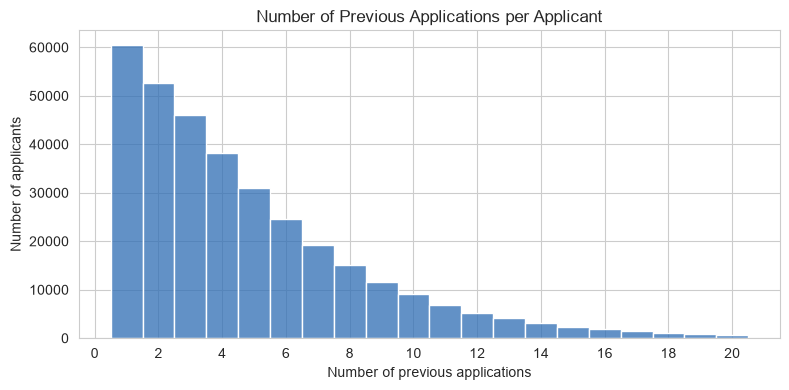

In [20]:
applications_per_applicant = previous.groupby("SK_ID_CURR")["SK_ID_PREV"].count()
display(applications_per_applicant.describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).to_frame("previous_application_count"))

plot_limit = applications_per_applicant.quantile(0.99)

plt.figure(figsize=(8, 4))
sns.histplot(
    applications_per_applicant[applications_per_applicant <= plot_limit],
    discrete=True,
    color=BLUE
)

plt.title("Number of Previous Applications per Applicant")
plt.xlabel("Number of previous applications")
plt.ylabel("Number of applicants")
plt.xticks(range(0, int(plot_limit) + 1, 2))

plt.tight_layout()
plt.show()


The plot is capped at the 99th percentile so the long tail does not make the chart hard to read. Those applicants are still in the data.


## Missing-value analysis


Columns containing missing values: 16


,missing_count,missing_percent
RATE_INTEREST_PRIMARY,1664263,99.64
RATE_INTEREST_PRIVILEGED,1664263,99.64
AMT_DOWN_PAYMENT,895844,53.64
RATE_DOWN_PAYMENT,895844,53.64
NAME_TYPE_SUITE,820405,49.12
DAYS_FIRST_DRAWING,673065,40.30
DAYS_FIRST_DUE,673065,40.30
DAYS_LAST_DUE_1ST_VERSION,673065,40.30
DAYS_LAST_DUE,673065,40.30
DAYS_TERMINATION,673065,40.30


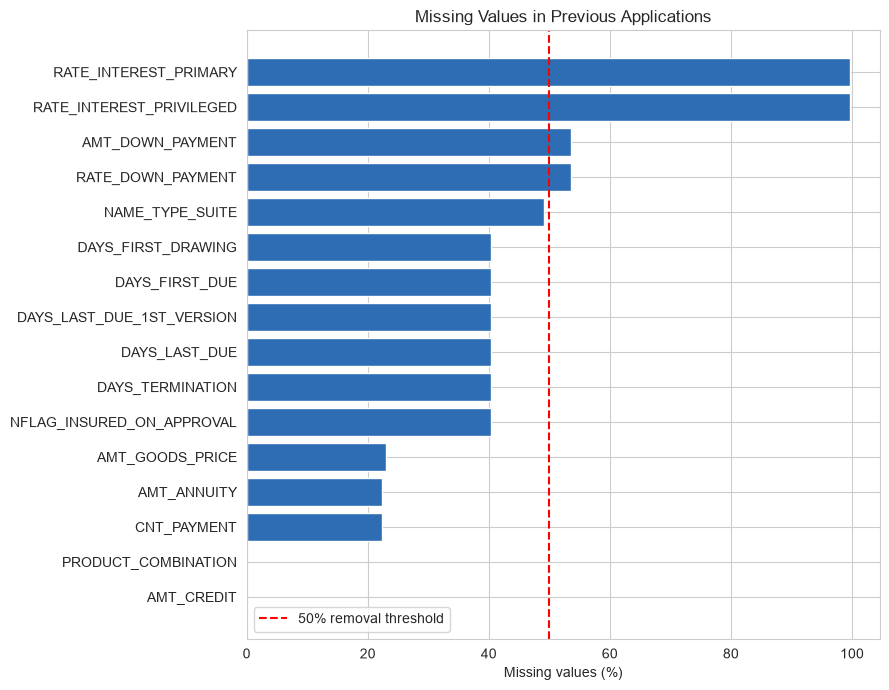

In [23]:
missing_summary = pd.DataFrame({
    "missing_count": previous.isna().sum(),
    "missing_percent": (previous.isna().mean() * 100).round(2)
})
missing_summary = missing_summary[missing_summary["missing_count"] > 0]
missing_summary = missing_summary.sort_values("missing_percent", ascending=False)

print("Columns containing missing values:", len(missing_summary))
display(missing_summary)

plt.figure(figsize=(9, 7))
plt.barh(missing_summary.index[::-1], missing_summary["missing_percent"][::-1], color=BLUE)
plt.axvline(50, color="red", linestyle="--", label="50% removal threshold")
plt.legend()
plt.title("Missing Values in Previous Applications")
plt.xlabel("Missing values (%)")
plt.tight_layout()
plt.show()

A few date columns look about 40% missing here, but they also use the 365243 placeholder value. The actual missing amount will be checked properly next.


## Placeholder values in date columns

Some date columns use 365243 to mean that a date is not available. This is checked separately from ordinary missing values.


In [26]:
sentinel_columns = [
    "DAYS_FIRST_DRAWING",
    "DAYS_FIRST_DUE",
    "DAYS_LAST_DUE_1ST_VERSION",
    "DAYS_LAST_DUE",
    "DAYS_TERMINATION",
]

sentinel_results = []
for column in sentinel_columns:
    count = (previous[column] == 365243).sum()
    existing_missing_count = previous[column].isna().sum()
    sentinel_results.append({
        "column": column,
        "existing_missing_count": existing_missing_count,
        "sentinel_count": count,
        "sentinel_percent": count / len(previous) * 100,
        "combined_unavailable_count": existing_missing_count + count,
        "combined_unavailable_percent": (existing_missing_count + count) / len(previous) * 100,
    })

sentinel_table = pd.DataFrame(sentinel_results)
sentinel_table.round(2)


,column,existing_missing_count,sentinel_count,sentinel_percent,combined_unavailable_count,combined_unavailable_percent
0,DAYS_FIRST_DRAWING,673065,934444,55.95,1607509,96.25
1,DAYS_FIRST_DUE,673065,40645,2.43,713710,42.73
2,DAYS_LAST_DUE_1ST_VERSION,673065,93864,5.62,766929,45.92
3,DAYS_LAST_DUE,673065,211221,12.65,884286,52.94
4,DAYS_TERMINATION,673065,225913,13.53,898978,53.82


365243 is not a real date, so it should be treated as missing. A few of these columns end up mostly unavailable once combined with the existing missing values. This will be kept in mind for cleaning.


## Application decision and categorical features


In [29]:
status_table = previous["NAME_CONTRACT_STATUS"].value_counts(dropna=False).to_frame("count")
status_table["percent"] = status_table["count"] / len(previous) * 100
status_table.round(2)


,count,percent
NAME_CONTRACT_STATUS,,
Approved,1036781,62.07
Canceled,316319,18.94
Refused,290678,17.40
Unused offer,26436,1.58


In [30]:
selected_categories = [
    "NAME_CONTRACT_TYPE",
    "NAME_CASH_LOAN_PURPOSE",
    "NAME_PAYMENT_TYPE",
    "CODE_REJECT_REASON",
    "NAME_CLIENT_TYPE",
    "NAME_PORTFOLIO",
    "NAME_PRODUCT_TYPE",
    "CHANNEL_TYPE",
]

for column in selected_categories:
    category_table = previous[column].value_counts(dropna=False).to_frame("count")
    category_table["percent"] = category_table["count"] / len(previous) * 100
    print("\n", column)
    display(category_table.head(20).round(2))



 NAME_CONTRACT_TYPE


,count,percent
NAME_CONTRACT_TYPE,,
Cash loans,747553,44.76
Consumer loans,729151,43.66
Revolving loans,193164,11.57
XNA,346,0.02



 NAME_CASH_LOAN_PURPOSE


,count,percent
NAME_CASH_LOAN_PURPOSE,,
XAP,922661,55.24
XNA,677918,40.59
Repairs,23765,1.42
Other,15608,0.93
Urgent needs,8412,0.50
Buying a used car,2888,0.17
Building a house or an annex,2693,0.16
Everyday expenses,2416,0.14
Medicine,2174,0.13



 NAME_PAYMENT_TYPE


...

,count,percent
NAME_PORTFOLIO,,
POS,691011,41.37
Cash,461563,27.63
XNA,372230,22.29
Cards,144985,8.68
Cars,425,0.03



 NAME_PRODUCT_TYPE


,count,percent
NAME_PRODUCT_TYPE,,
XNA,1063666,63.68
x-sell,456287,27.32
walk-in,150261,9.00



 CHANNEL_TYPE


,count,percent
CHANNEL_TYPE,,
Credit and cash offices,719968,43.11
Country-wide,494690,29.62
Stone,212083,12.70
Regional / Local,108528,6.50
Contact center,71297,4.27
AP+ (Cash loan),57046,3.42
Channel of corporate sales,6150,0.37
Car dealer,452,0.03


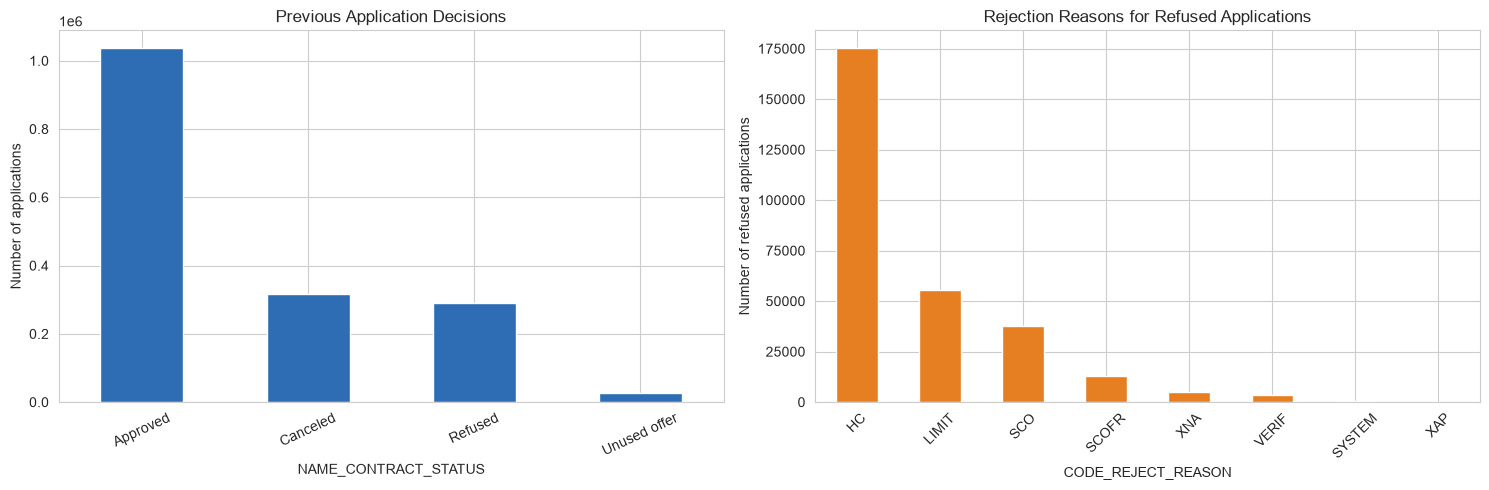

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

previous["NAME_CONTRACT_STATUS"].value_counts().plot(kind="bar", ax=axes[0], color=BLUE)

axes[0].set_title("Previous Application Decisions")
axes[0].set_ylabel("Number of applications")
axes[0].tick_params(axis="x", rotation=25)

refused_applications = previous[previous["NAME_CONTRACT_STATUS"] == "Refused"]

refused_applications["CODE_REJECT_REASON"].value_counts().plot(kind="bar", ax=axes[1], color=ORANGE)
axes[1].set_title("Rejection Reasons for Refused Applications")
axes[1].set_ylabel("Number of refused applications")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Most previous applications were approved. XNA and XAP values show up in a few categorical columns, and they generally mean the category was not applicable.


## Amounts and basic domain checks

Looking at the main amount columns and running a few simple checks, such as negative amounts and future dates. Nothing is removed automatically, since some unusual values could be real.


In [34]:
amount_columns = [
    "AMT_ANNUITY",
    "AMT_APPLICATION",
    "AMT_CREDIT",
    "AMT_DOWN_PAYMENT",
    "AMT_GOODS_PRICE",
]

amount_summary = previous[amount_columns].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
).T
amount_summary[["count", "mean", "min", "1%", "50%", "99%", "max"]]


,count,mean,min,1%,50%,99%,max
AMT_ANNUITY,1297979.0,15955.120659,0.0,2137.1751,11250.0,6.968579e+04,418058.145
AMT_APPLICATION,1670214.0,175233.860360,0.0,0.0000,71046.0,1.350000e+06,6905160.000
AMT_CREDIT,1670213.0,196114.021218,0.0,0.0000,80541.0,1.515378e+06,6905160.000
AMT_DOWN_PAYMENT,774370.0,6697.402139,-0.9,0.0000,1638.0,6.593089e+04,3060045.000
AMT_GOODS_PRICE,1284699.0,227847.279283,0.0,15300.0000,112320.0,1.395000e+06,6905160.000


In [35]:
domain_checks = pd.DataFrame({
    "check": [
        "Negative requested amount",
        "Negative credit amount",
        "Negative annuity amount",
        "Negative down payment",
        "Negative payment count",
        "Future decision date",
        "Seller area recorded as -1",
        "Credit greater than requested amount",
        "Requested amount equal to zero"
    ],
    "rows_affected": [
        (previous["AMT_APPLICATION"] < 0).sum(),
        (previous["AMT_CREDIT"] < 0).sum(),
        (previous["AMT_ANNUITY"] < 0).sum(),
        (previous["AMT_DOWN_PAYMENT"] < 0).sum(),
        (previous["CNT_PAYMENT"] < 0).sum(),
        (previous["DAYS_DECISION"] > 0).sum(),
        (previous["SELLERPLACE_AREA"] == -1).sum(),
        (previous["AMT_CREDIT"] > previous["AMT_APPLICATION"]).sum(),
        (previous["AMT_APPLICATION"] == 0).sum()
    ]
})

domain_checks

,check,rows_affected
0,Negative requested amount,0
1,Negative credit amount,0
2,Negative annuity amount,0
3,Negative down payment,2
4,Negative payment count,0
5,Future decision date,0
6,Seller area recorded as -1,762675
7,Credit greater than requested amount,657636
8,Requested amount equal to zero,392402


Nothing major was found. SELLERPLACE_AREA uses -1 as a placeholder, and some records have a zero requested amount or a credit amount higher than requested. These will be flagged during cleaning instead of removed.


### Requested amount vs recorded credit amount


In [38]:
amount_comparison = previous[["AMT_APPLICATION", "AMT_CREDIT", "NAME_CONTRACT_STATUS"]].copy()
amount_comparison["CREDIT_MINUS_REQUESTED"] = amount_comparison["AMT_CREDIT"] - amount_comparison["AMT_APPLICATION"]

print("Rows with zero requested amount:", (amount_comparison["AMT_APPLICATION"] == 0).sum())
print("Recorded credit lower than requested:", (amount_comparison["CREDIT_MINUS_REQUESTED"] < 0).sum())
print("Recorded credit equal to requested:", (amount_comparison["CREDIT_MINUS_REQUESTED"] == 0).sum())
print("Recorded credit greater than requested:", (amount_comparison["CREDIT_MINUS_REQUESTED"] > 0).sum())
display(amount_comparison["CREDIT_MINUS_REQUESTED"].describe(percentiles=[0.01, 0.50, 0.99]))

zero_requested_by_status = pd.crosstab(
    amount_comparison["NAME_CONTRACT_STATUS"],
    amount_comparison["AMT_APPLICATION"] == 0,
)
zero_requested_by_status.columns = ["nonzero_requested_amount", "zero_requested_amount"]
zero_requested_by_status["zero_percent_within_status"] = (
    zero_requested_by_status["zero_requested_amount"] / zero_requested_by_status.sum(axis=1) * 100
)
zero_requested_by_status.round(2)


Rows with zero requested amount: 392402
Recorded credit lower than requested: 357691
Recorded credit equal to requested: 654886
Recorded credit greater than requested: 657636


count    1.670213e+06
mean     2.088006e+04
std      7.193908e+04
min     -3.020450e+06
1%      -4.147146e+04
50%      0.000000e+00
99%      3.600000e+05
max      1.350000e+06
Name: CREDIT_MINUS_REQUESTED, dtype: float64

,nonzero_requested_amount,zero_requested_amount,zero_percent_within_status
NAME_CONTRACT_STATUS,,,
Approved,991477,45304,4.37
Canceled,10741,305578,96.60
Refused,249652,41026,14.11
Unused offer,25942,494,1.87


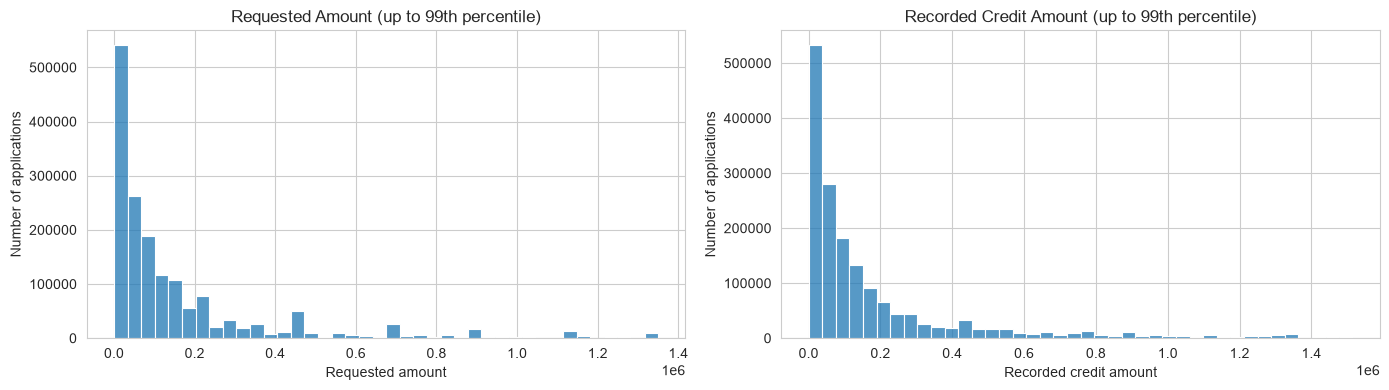

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

application_limit = previous["AMT_APPLICATION"].quantile(0.99)
credit_limit = previous["AMT_CREDIT"].quantile(0.99)

sns.histplot(previous.loc[previous["AMT_APPLICATION"] <= application_limit, "AMT_APPLICATION"], bins=40, ax=axes[0])
sns.histplot(previous.loc[previous["AMT_CREDIT"] <= credit_limit, "AMT_CREDIT"], bins=40, ax=axes[1])

axes[0].set_title("Requested Amount (up to 99th percentile)")
axes[1].set_title("Recorded Credit Amount (up to 99th percentile)")

axes[0].set_xlabel("Requested amount")
axes[1].set_xlabel("Recorded credit amount")

axes[0].set_ylabel("Number of applications")
axes[1].set_ylabel("Number of applications")
plt.tight_layout()
plt.show()


Both amounts are right-skewed, as expected. Many of the zero-requested-amount rows belong to cancelled applications, so zero is not always an error. The difference between the credit amount and the requested amount could also be a useful feature later.


## Applicant-level target comparison

Building a few quick applicant-level summaries, such as approval and refusal counts and amounts, just for this comparison. These are not the final features.


In [42]:
previous_labelled = previous[previous["SK_ID_CURR"].isin(labelled_applicant_ids)].copy()

previous_labelled["IS_APPROVED"] = (previous_labelled["NAME_CONTRACT_STATUS"] == "Approved").astype(int)
previous_labelled["IS_REFUSED"] = (previous_labelled["NAME_CONTRACT_STATUS"] == "Refused").astype(int)
previous_labelled["IS_CANCELED"] = (previous_labelled["NAME_CONTRACT_STATUS"] == "Canceled").astype(int)
previous_labelled["CREDIT_MINUS_REQUESTED"] = previous_labelled["AMT_CREDIT"] - previous_labelled["AMT_APPLICATION"]

applicant_previous = previous_labelled.groupby("SK_ID_CURR").agg(
    PREVIOUS_APPLICATION_COUNT=("SK_ID_PREV", "count"),
    APPROVED_COUNT=("IS_APPROVED", "sum"),
    REFUSED_COUNT=("IS_REFUSED", "sum"),
    CANCELED_COUNT=("IS_CANCELED", "sum"),
    APPROVAL_RATE=("IS_APPROVED", "mean"),
    REFUSAL_RATE=("IS_REFUSED", "mean"),
    AVERAGE_REQUESTED_AMOUNT=("AMT_APPLICATION", "mean"),
    AVERAGE_CREDIT_AMOUNT=("AMT_CREDIT", "mean"),
    AVERAGE_CREDIT_DIFFERENCE=("CREDIT_MINUS_REQUESTED", "mean"),
    MOST_RECENT_DECISION_DAYS=("DAYS_DECISION", "max"),
).reset_index()

applicant_previous.head()


,SK_ID_CURR,PREVIOUS_APPLICATION_COUNT,APPROVED_COUNT,REFUSED_COUNT,CANCELED_COUNT,APPROVAL_RATE,REFUSAL_RATE,AVERAGE_REQUESTED_AMOUNT,AVERAGE_CREDIT_AMOUNT,AVERAGE_CREDIT_DIFFERENCE,MOST_RECENT_DECISION_DAYS
0,100002,1,1,0,0,1.000000,0.000000,179055.00,179055.00,0.00,-606
1,100003,3,3,0,0,1.000000,0.000000,435436.50,484191.00,48754.50,-746
2,100004,1,1,0,0,1.000000,0.000000,24282.00,20106.00,-4176.00,-815
3,100006,9,5,1,3,0.555556,0.111111,272203.26,291695.50,19492.24,-181
4,100007,6,6,0,0,1.000000,0.000000,150530.25,166638.75,16108.50,-374


### Applicant-level relationships with default


In [44]:
applicant_previous_target = application_target.merge(applicant_previous, on="SK_ID_CURR", how="left")

feature_columns = [
    "PREVIOUS_APPLICATION_COUNT",
    "APPROVED_COUNT",
    "REFUSED_COUNT",
    "CANCELED_COUNT",
    "APPROVAL_RATE",
    "REFUSAL_RATE",
    "AVERAGE_REQUESTED_AMOUNT",
    "AVERAGE_CREDIT_AMOUNT",
    "AVERAGE_CREDIT_DIFFERENCE",
    "MOST_RECENT_DECISION_DAYS",
]

feature_correlations = applicant_previous_target[feature_columns + ["TARGET"]].corr()["TARGET"].drop("TARGET")
feature_correlations.sort_values().to_frame("correlation_with_target").round(4)


,correlation_with_target
APPROVAL_RATE,-0.0635
APPROVED_COUNT,-0.0316
AVERAGE_REQUESTED_AMOUNT,-0.0218
AVERAGE_CREDIT_AMOUNT,-0.0161
MOST_RECENT_DECISION_DAYS,0.0164
AVERAGE_CREDIT_DIFFERENCE,0.0181
CANCELED_COUNT,0.0190
PREVIOUS_APPLICATION_COUNT,0.0198
REFUSED_COUNT,0.0645
REFUSAL_RATE,0.0777


In [45]:
applicant_previous_target["HAS_REFUSAL"] = applicant_previous_target["REFUSED_COUNT"].fillna(0) > 0
refusal_default_summary = applicant_previous_target.groupby("HAS_REFUSAL")["TARGET"].agg(["count", "mean"])
refusal_default_summary["default_rate_percent"] = refusal_default_summary["mean"] * 100
refusal_default_summary.drop(columns="mean").round(2)


,count,default_rate_percent
HAS_REFUSAL,,
False,207217,6.98
True,100294,10.32


The refusal rate has the strongest positive correlation with default here, and the approval rate has a negative correlation. These correlations are still fairly small, so they are not enough on their own to select or drop features.


## Main findings

The previous-application dataset contains several application records for many applicants. It will therefore need to be summarized before it can be merged with the main application data.

The main findings are:

- Previous-application history is available for 94.65% of labelled applicants.
- Half of the applicants have 4 or fewer previous applications.
- Several columns contain high levels of missing data.
- Some date columns use `365243` as a missing-value placeholder.
- Most previous applications were approved.
- Cash loans and consumer loans were the most common contract types.
- Some categorical values and rejection reasons occur very rarely.
- `SELLERPLACE_AREA` frequently uses `-1` as a placeholder.
- Zero requested amounts are common, especially among cancelled applications.
- Previous refusal history is associated with a higher default rate.
- Application counts, approval rates, refusal rates and amount differences may be useful applicant-level features.

Based on these findings, the cleaning stage will convert placeholder values, combine rare categories, remove features with very high missingness and retain useful unusual-value information through indicator columns.
